In [2]:
!pip install langraph

ERROR: Could not find a version that satisfies the requirement langraph (from versions: none)
ERROR: No matching distribution found for langraph


In [3]:
from langgraph.graph import StateGraph,END
import random
from typing import Dict,List,TypedDict

In [4]:
class Agent(TypedDict):
  name:str
  number: list[int]
  counter:int

In [5]:
def greeting_node(state:Agent)-> Agent:
  """greeting node which says hi to the person"""
  state['name']=f"HI there ,{state["name"]}"
  state['counter']=0
  return state
def random_node(state:Agent)-> Agent:
  """generate a random=n numbver from 0 to 10"""
  state['number'].append(random.randint(0,10))
  state['counter'] += 1
  return state
def should_continue(state:Agent)-> Agent:
  if state["counter"]<5:
    print("Entering the loop",state['counter']
          )
    return 'loop'
  else:
    return "exit"


In [6]:
graph=StateGraph(Agent)
graph.add_node('greeting',greeting_node)
graph.add_node("random",random_node)
graph.add_edge("greeting","random")
graph.add_conditional_edges(
    "random",
    should_continue,
    {"loop":"random",
     "exit":END}
)
graph.set_entry_point('greeting')

In [7]:
app=graph.compile()

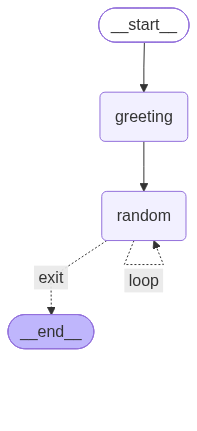

In [8]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
app.invoke(
    {
    "name":'anushka','number':[],"counter":-1

})

Entering the loop 1
Entering the loop 2
Entering the loop 3
Entering the loop 4


{'name': 'HI there ,anushka', 'number': [1, 9, 0, 7, 9], 'counter': 5}

In [10]:

#agent1 #simplebot
!pip install -U langgraph langchain langchain-core langchain-community langchain-openai python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.9/248.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.0/147.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.9/565.9 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.7/123.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9
  Attempting uninstal

In [11]:
!pip install -U langchain-google-genai python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.3/73.3 kB 4.2 MB/s eta 0:00:00


In [12]:
from typing import TypedDict, List,Union
from langchain_core.messages import HumanMessage,AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI


In [13]:
load_dotenv()
import os
from getpass import getpass
#AQ.Ab8RN6J6MlFEdgn9kI6B00D9BD6MTO08KD6AvLI44cKyLQ1wXw
os.environ["GOOGLE_API_KEY"] = getpass("Enter your Gemini API key: ")

Enter your Gemini API key: ··········


In [14]:
class AgentState(TypedDict):
  messages:List[HumanMessage]
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [15]:
def process(state:AgentState)-> AgentState:
  response=llm.invoke(state['messages'])
  return {"messages": [response]}

In [16]:
graph=StateGraph(AgentState)
graph.add_node('process',process)
graph.add_edge(START,'process')
graph.add_edge("process",END)
agent=graph.compile()

In [17]:
user_input = input("Enter: ")
while True:
    user_input = input("You: ")

    if user_input.lower() in ["exit", "quit", "bye"]:
        print("Chat ended.")
        break

    result = agent.invoke({
        "messages": [HumanMessage(content=user_input)]
    })

    print("AI:", result["messages"][-1].content)

Enter: hie


KeyboardInterrupt: Interrupted by user

In [ ]:
#llm is stateless so no memory.
#AIAGNET2
!pip install Union

In [18]:
class AgentState(TypedDict):
  messages:List[Union[HumanMessage,AIMessage]]
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [19]:
def process(state:AgentState)-> AgentState:
  """this node will solve the request you input"""
  response=llm.invoke(state['messages'])
  state['messages'].append(AIMessage(content=response.content))
  print(f"\nAI : {response.content}")
  return state

In [20]:
graph=StateGraph(AgentState)
graph.add_node('process',process)
graph.add_edge(START,'process')
graph.add_edge("process",END)
agent=graph.compile()

In [24]:
conversation_history = []

while True:

    user_input = input("You: ")

    if user_input.lower() in ["exit", "quit", "bye"]:
        print("Chat ended.")
        break

    # Add user's message to conversation history
    conversation_history.append(
        HumanMessage(content=user_input)
    )

    # Send complete conversation history to LangGraph
    result = agent.invoke({
        "messages": conversation_history
    })


with open("conversation_history.txt", "w") as file:
    for message in conversation_history:
        if isinstance(message,HumanMessage):
          file.write(f"you: {message.content}\n")
        elif isinstance(message,AIMessage):
          file.write(f"AI: {message.content}\n")


print("conversation saved to conversation_history.txt")

KeyboardInterrupt: Interrupted by user

In [ ]:
#as the context window is incresing so what we can do is if we have 5 question while the 6th comes in reomve the earliest I.E the first one out.